# Experimento 2 — Comparación unificada de transferencia

Carga los `summary.csv` de los tres modelos (N-BEATS, TFT, LSTM) y produce las visualizaciones
comparativas del Capítulo 5 de la tesis.

**Prerequisito:** ejecutar primero `01_nbeats_transfer.ipynb`, `02_tft_transfer.ipynb` y
`03_lstm_transfer.ipynb` para que existan los `summary.csv` en `results/ex2_transfer/{modelo}/`.

## Celdas
| # | Celda | Propósito |
|---|-------|-----------|
| 1 | `cell-01-setup` | Setup, rutas, carga de datos |
| 2 | `cell-02-load` | Cargar y unificar los 3 `summary.csv` |
| 3 | `cell-03-heatmap` | Heatmap MAE (modelo × escenario) — figura central del Cap. 5 |
| 4 | `cell-04-efficiency` | Data efficiency curve (línea continua log-escala) |
| 5 | `cell-05-zeroshot` | Zero-shot vs baseline por modelo |
| 6 | `cell-06-frozen` | Frozen vs full fine-tuning por modelo |
| 7 | `cell-07-similarity` | Similaridad de plantas → rendimiento de transferencia |
| 8 | `cell-08-export` | Tabla resumen y export a CSV |

In [1]:
##########################################
# Añadir esto al principio de cada ipynb #
##########################################
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/_UOC/tfm-solar-forecasting/')

# Verifica que existan las carpetas esperadas
!ls
# Debes ver 'src' y 'config'

Mounted at /content/drive
checkpoints  data  lightning_logs  README.md	     results
config	     doc   notebooks	   requirements.txt  src


In [2]:
# ============================================================================
# 1. SETUP
# ============================================================================

import sys
import pathlib as _pl
_root = next(
    (p for p in [_pl.Path.cwd(), *_pl.Path.cwd().parents]
     if (p / 'src').is_dir() and (p / 'data' / 'processed').is_dir()),
    None
)
if _root is None:
    raise RuntimeError(
        f"No se encontró src/. cwd={_pl.Path.cwd()}\n"
        "En Colab: monta Drive y ejecuta os.chdir() al repo antes de %run."
    )
sys.path.insert(0, str(_root / 'src'))
REPO_ROOT = _root
del _pl, _root

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance  import pdist, squareform
from sklearn.preprocessing   import StandardScaler
from sklearn.decomposition   import PCA
from matplotlib.lines        import Line2D

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Rutas de resultados de cada modelo ───────────────────────────────────────
RESULTS_NBEATS = REPO_ROOT / 'results' / 'ex2_transfer' / 'nbeats'
RESULTS_TFT    = REPO_ROOT / 'results' / 'ex2_transfer' / 'tft'
RESULTS_LSTM   = REPO_ROOT / 'results' / 'ex2_transfer' / 'lstm'
DATA_DIR       = REPO_ROOT / 'data' / 'processed'
RESULTS_CMP    = REPO_ROOT / 'results' / 'ex2_transfer' / 'comparison'
RESULTS_CMP.mkdir(parents=True, exist_ok=True)
FIGURES_DIR    = RESULTS_CMP / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PLANTA_TARGET  = 'TALASOL'
PLANTAS_SOURCE = ['UPGARNACHA', 'FVARENA', 'NBALBOA', 'RODRI', 'UFMULA']

# Paleta semántica (consistente con notebooks individuales)
COLORES_MODELO = {
    'N-BEATS': '#1565C0',
    'TFT':     '#C62828',
    'LSTM':    '#2E7D32',
}
MODELOS = list(COLORES_MODELO.keys())

# Orden de escenarios
SCENARIO_ORDER = [
    'zero_shot',
    'ft_1_semana',        'ft_frozen_1_semana',
    'ft_1_mes',           'ft_frozen_1_mes',
    'ft_3_meses',         'ft_frozen_3_meses',
    'baseline',
]

# Horas de fine-tuning para el eje de data efficiency
FT_HOURS = {
    'zero_shot':   0,
    'ft_1_semana': 168,
    'ft_1_mes':    720,
    'ft_3_meses':  2160,
    'ft_frozen_1_semana': 168,
    'ft_frozen_1_mes':    720,
    'ft_frozen_3_meses':  2160,
    'baseline':    None,
}

print('=' * 70)
print('EXPERIMENTO 2: COMPARACIÓN UNIFICADA DE TRANSFER LEARNING')
print(f'Planta target : {PLANTA_TARGET}')
print(f'Plantas fuente: {PLANTAS_SOURCE}')
print(f'Resultados    : {RESULTS_CMP}')
print('=' * 70)

EXPERIMENTO 2: COMPARACIÓN UNIFICADA DE TRANSFER LEARNING
Planta target : TALASOL
Plantas fuente: ['UPGARNACHA', 'FVARENA', 'NBALBOA', 'RODRI', 'UFMULA']
Resultados    : /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/comparison


In [3]:
# ============================================================================
# 2. CARGA Y UNIFICACIÓN DE summary.csv DE LOS 3 MODELOS
# ============================================================================

def load_summary(results_dir: Path, model_name: str) -> pd.DataFrame:
    """Carga summary.csv de un modelo y añade columna 'modelo'."""
    csv_path = results_dir / 'summary.csv'
    if not csv_path.exists():
        print(f'  [AVISO] No encontrado: {csv_path}')
        print(f'  → Ejecuta primero el notebook de {model_name}')
        return None
    df = pd.read_csv(csv_path)
    df['modelo'] = model_name
    print(f'  {model_name}: {len(df)} escenarios  |  '
          f'MAE: {df["MAE"].min():.2f}–{df["MAE"].max():.2f} MW')
    return df


print('[2/8] Cargando summary.csv...')
df_nbeats = load_summary(RESULTS_NBEATS, 'N-BEATS')
df_tft    = load_summary(RESULTS_TFT,    'TFT')
df_lstm   = load_summary(RESULTS_LSTM,   'LSTM')

dfs = [df for df in [df_nbeats, df_tft, df_lstm] if df is not None]
if not dfs:
    raise RuntimeError(
        'No hay ningún summary.csv disponible. '
        'Ejecuta primero los notebooks de transfer learning (01, 02, 03).'
    )

df_all = pd.concat(dfs, ignore_index=True)
modelos_disponibles = df_all['modelo'].unique().tolist()
print(f'\nModelos disponibles: {modelos_disponibles}')
print(f'Total filas: {len(df_all)}')

# Orden de escenarios
df_all['_order'] = df_all['scenario'].map(
    {s: i for i, s in enumerate(SCENARIO_ORDER)}
).fillna(99)
df_all = df_all.sort_values(['modelo', '_order']).drop(columns='_order')

# Añadir n_ft_hours si no existe
if 'n_ft_hours' not in df_all.columns:
    df_all['n_ft_hours'] = df_all['scenario'].map(
        {k: v for k, v in FT_HOURS.items() if v is not None}
    )

print('\nVista previa:')
display_cols = ['modelo', 'scenario', 'MAE', 'RMSE', 'R2', 'mejora_vs_baseline_%']
display_cols = [c for c in display_cols if c in df_all.columns]
print(df_all[display_cols].to_string(index=False))

[2/8] Cargando summary.csv...
  N-BEATS: 8 escenarios  |  MAE: 27.29–30.18 MW
  TFT: 8 escenarios  |  MAE: 25.00–33.99 MW
  LSTM: 8 escenarios  |  MAE: 46.87–84.18 MW

Modelos disponibles: ['N-BEATS', 'TFT', 'LSTM']
Total filas: 24

Vista previa:
 modelo           scenario     MAE     RMSE     R2  mejora_vs_baseline_%
   LSTM          zero_shot 52.1449 116.1262 0.6439               38.0600
   LSTM        ft_1_semana 53.0944 118.2397 0.6309               36.9300
   LSTM ft_frozen_1_semana 56.2467 122.2297 0.6055               33.1900
   LSTM           ft_1_mes 46.8656 103.2712 0.7184               44.3300
   LSTM    ft_frozen_1_mes 62.0934 133.5934 0.5288               26.2400
   LSTM         ft_3_meses 56.3990 123.9864 0.5941               33.0100
   LSTM  ft_frozen_3_meses 76.5299 160.5324 0.3196                9.0900
   LSTM           baseline 84.1844 175.4099 0.1876                0.0000
N-BEATS          zero_shot 28.5360  63.4111 0.8880               -4.5800
N-BEATS        ft_1_sem

[3/8] Heatmap MAE (modelo × escenario)...


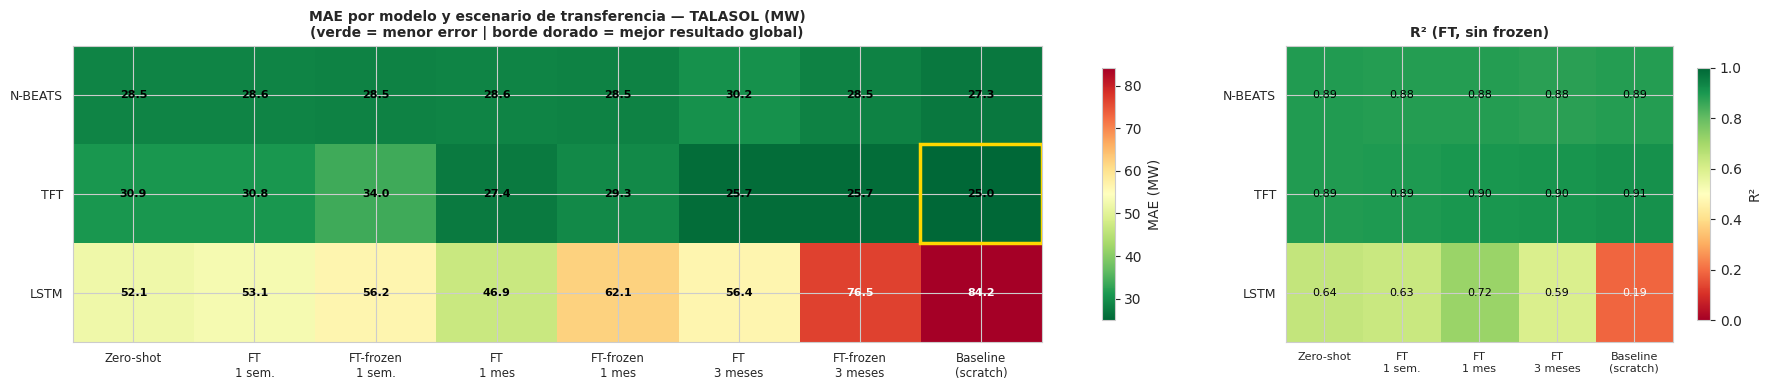

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/comparison/figures/exp2_heatmap_mae_r2.png

Ranking global (MAE mínimo por modelo):
 modelo  MAE_min escenario_optimo
    TFT  24.9984         baseline
N-BEATS  27.2870         baseline
   LSTM  46.8656         ft_1_mes


In [4]:
# ============================================================================
# 3. HEATMAP MAE (modelo × escenario) — Figura central del Capítulo 5
# ============================================================================
# Muestra de un vistazo qué modelo/escenario produce el mejor MAE en TALASOL.
# Responde directamente a H2: ¿qué modelo transfiere mejor?

print('[3/8] Heatmap MAE (modelo × escenario)...')

# Pivotar: filas = modelo, columnas = escenario
pivot_mae = df_all.pivot_table(
    index='modelo', columns='scenario', values='MAE', aggfunc='mean'
)
# Reordenar columnas al orden lógico
ordered_cols = [c for c in SCENARIO_ORDER if c in pivot_mae.columns]
pivot_mae = pivot_mae[ordered_cols].reindex(MODELOS, fill_value=np.nan)

# Etiquetas de columna más legibles
col_labels = {
    'zero_shot':          'Zero-shot',
    'ft_1_semana':        'FT\n1 sem.',
    'ft_frozen_1_semana': 'FT-frozen\n1 sem.',
    'ft_1_mes':           'FT\n1 mes',
    'ft_frozen_1_mes':    'FT-frozen\n1 mes',
    'ft_3_meses':         'FT\n3 meses',
    'ft_frozen_3_meses':  'FT-frozen\n3 meses',
    'baseline':           'Baseline\n(scratch)',
}

fig, axes = plt.subplots(1, 2, figsize=(18, 4),
                          gridspec_kw={'width_ratios': [2.5, 1]})

# ── Panel izquierdo: heatmap MAE ────────────────────────────────────────────
ax_h = axes[0]
pivot_disp = pivot_mae.copy()
pivot_disp.columns = [col_labels.get(c, c) for c in pivot_disp.columns]
pivot_disp.index.name = None

vmin = pivot_disp.min().min()
vmax = pivot_disp.max().max()
im = ax_h.imshow(pivot_disp.values, cmap='RdYlGn_r',
                  aspect='auto', vmin=vmin, vmax=vmax)
plt.colorbar(im, ax=ax_h, label='MAE (MW)', shrink=0.85)

n_rows, n_cols = pivot_disp.shape
ax_h.set_xticks(range(n_cols))
ax_h.set_yticks(range(n_rows))
ax_h.set_xticklabels(pivot_disp.columns, fontsize=8.5)
ax_h.set_yticklabels(pivot_disp.index,   fontsize=9)

# Anotar valores en cada celda
for i in range(n_rows):
    for j in range(n_cols):
        val = pivot_disp.iloc[i, j]
        if not np.isnan(val):
            # Texto blanco si fondo oscuro, negro si claro
            normed = (val - vmin) / (vmax - vmin + 1e-9)
            txt_color = 'white' if normed > 0.65 else 'black'
            ax_h.text(j, i, f'{val:.1f}', ha='center', va='center',
                      fontsize=8, color=txt_color, fontweight='bold')

# Resaltar el mínimo global con borde amarillo
min_val = np.nanmin(pivot_disp.values)
for i in range(n_rows):
    for j in range(n_cols):
        if not np.isnan(pivot_disp.iloc[i, j]) and \
                abs(pivot_disp.iloc[i, j] - min_val) < 1e-6:
            rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                   fill=False, edgecolor='gold',
                                   linewidth=2.5, zorder=3)
            ax_h.add_patch(rect)

ax_h.set_title(
    f'MAE por modelo y escenario de transferencia — {PLANTA_TARGET} (MW)\n'
    '(verde = menor error | borde dorado = mejor resultado global)',
    fontsize=10, fontweight='bold'
)

# ── Panel derecho: heatmap R² ────────────────────────────────────────────────
if 'R2' in df_all.columns:
    ax_r = axes[1]
    pivot_r2 = df_all.pivot_table(
        index='modelo', columns='scenario', values='R2', aggfunc='mean'
    )
    pivot_r2 = pivot_r2[ordered_cols].reindex(MODELOS, fill_value=np.nan)
    pivot_r2.columns = [col_labels.get(c, c) for c in pivot_r2.columns]
    pivot_r2.index.name = None

    # Mostrar solo columnas sin frozen para simplificar
    non_frozen_cols = [c for c in pivot_r2.columns if 'frozen' not in c]
    pivot_r2_show = pivot_r2[non_frozen_cols]

    im_r = ax_r.imshow(pivot_r2_show.values, cmap='RdYlGn',
                        aspect='auto', vmin=0, vmax=1)
    plt.colorbar(im_r, ax=ax_r, label='R²', shrink=0.85)
    nr, nc = pivot_r2_show.shape
    ax_r.set_xticks(range(nc))
    ax_r.set_yticks(range(nr))
    ax_r.set_xticklabels(pivot_r2_show.columns, fontsize=8)
    ax_r.set_yticklabels(pivot_r2_show.index,   fontsize=9)
    for i in range(nr):
        for j in range(nc):
            val = pivot_r2_show.iloc[i, j]
            if not np.isnan(val):
                txt_color = 'white' if val < 0.35 else 'black'
                ax_r.text(j, i, f'{val:.2f}', ha='center', va='center',
                           fontsize=8, color=txt_color)
    ax_r.set_title('R² (FT, sin frozen)', fontsize=10, fontweight='bold')

plt.tight_layout()
save_path = FIGURES_DIR / 'exp2_heatmap_mae_r2.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Guardado: {save_path}')

# Imprimir ranking
print('\nRanking global (MAE mínimo por modelo):')
ranking = (
    df_all
    .groupby('modelo')['MAE']
    .min()
    .sort_values()
    .reset_index()
)
ranking.columns = ['modelo', 'MAE_min']
ranking['escenario_optimo'] = ranking['modelo'].map(
    lambda m: df_all[df_all['modelo'] == m].loc[
        df_all[df_all['modelo'] == m]['MAE'].idxmin(), 'scenario'
    ]
)
print(ranking.to_string(index=False))

[4/8] Data efficiency curve...


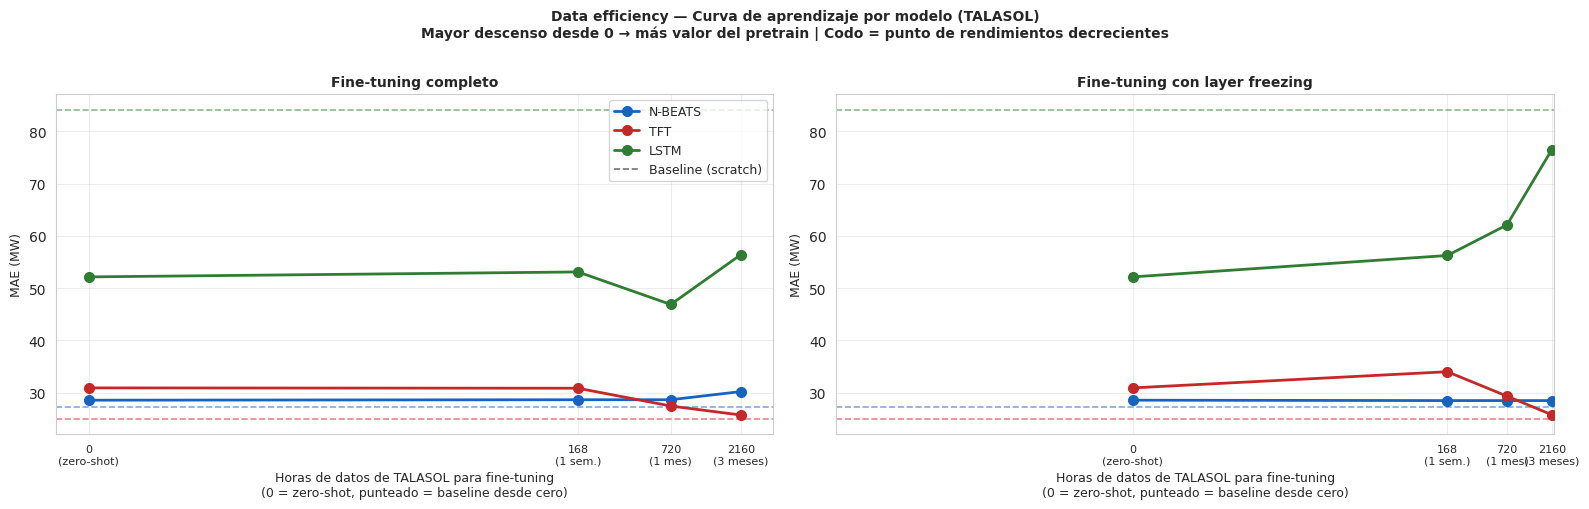

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/comparison/figures/exp2_data_efficiency_curve.png


In [5]:
# ============================================================================
# 4. DATA EFFICIENCY CURVE — curva de aprendizaje continua (log-escala)
# ============================================================================
# Eje X: horas de fine-tuning disponibles (0 = zero-shot, ..., 2160 = 3 meses)
# Eje Y: MAE en test de TALASOL
# Línea punteada: baseline desde cero (sin transferencia)
#
# Muestra:
#   - La ganancia del pretrain solo (0 horas) vs entrenar desde cero
#   - La velocidad de convergencia de cada modelo
#   - El punto de rendimientos decrecientes ("codo")

print('[4/8] Data efficiency curve...')

# Escenarios de FT completo (sin frozen) + zero-shot
ft_scenarios = ['zero_shot', 'ft_1_semana', 'ft_1_mes', 'ft_3_meses']
ft_frozen_scenarios = ['zero_shot', 'ft_frozen_1_semana',
                        'ft_frozen_1_mes', 'ft_frozen_3_meses']
ft_x = [0, 168, 720, 2160]   # horas

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

for ax_idx, (scenarios, x_vals, title_suffix) in enumerate([
    (ft_scenarios,        ft_x, 'Fine-tuning completo'),
    (ft_frozen_scenarios, ft_x, 'Fine-tuning con layer freezing'),
]):
    ax = axes[ax_idx]

    for modelo in modelos_disponibles:
        df_m  = df_all[df_all['modelo'] == modelo]
        color = COLORES_MODELO.get(modelo, '#607D8B')

        # Extraer MAE para cada escenario de FT
        mae_ft = []
        x_ft   = []
        for sc, xv in zip(scenarios, x_vals):
            row = df_m[df_m['scenario'] == sc]
            if len(row) > 0:
                mae_ft.append(row['MAE'].values[0])
                x_ft.append(xv)

        if len(x_ft) < 2:
            continue

        # Curva de FT
        ax.plot(x_ft, mae_ft, 'o-', color=color, lw=2, ms=7,
                label=modelo, zorder=3)

        # Línea punteada: baseline desde cero
        row_bl = df_m[df_m['scenario'] == 'baseline']
        if len(row_bl) > 0:
            bl_mae = row_bl['MAE'].values[0]
            ax.axhline(y=bl_mae, color=color, ls='--', lw=1.2,
                       alpha=0.55, zorder=2)

    ax.set_xscale('symlog', linthresh=1)   # log pero con 0 incluido
    ax.set_xlabel(
        'Horas de datos de TALASOL para fine-tuning\n'
        '(0 = zero-shot, punteado = baseline desde cero)',
        fontsize=9
    )
    ax.set_ylabel('MAE (MW)', fontsize=9)
    ax.set_title(title_suffix, fontsize=10, fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_xticks([0, 168, 720, 2160])
    ax.set_xticklabels(['0\n(zero-shot)', '168\n(1 sem.)', '720\n(1 mes)', '2160\n(3 meses)'],
                        fontsize=8)
    ax.grid(alpha=0.35)

    if ax_idx == 0:
        ax.legend(fontsize=9, loc='upper right')
        # Añadir leyenda de línea punteada
        ax.plot([], [], 'k--', lw=1.2, alpha=0.55, label='Baseline (scratch)')
        ax.legend(fontsize=9, loc='upper right')

plt.suptitle(
    f'Data efficiency — Curva de aprendizaje por modelo ({PLANTA_TARGET})\n'
    'Mayor descenso desde 0 → más valor del pretrain | Codo = punto de rendimientos decrecientes',
    fontsize=10, fontweight='bold', y=1.01
)
plt.tight_layout()
save_path = FIGURES_DIR / 'exp2_data_efficiency_curve.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Guardado: {save_path}')

[5/8] Zero-shot vs Baseline...


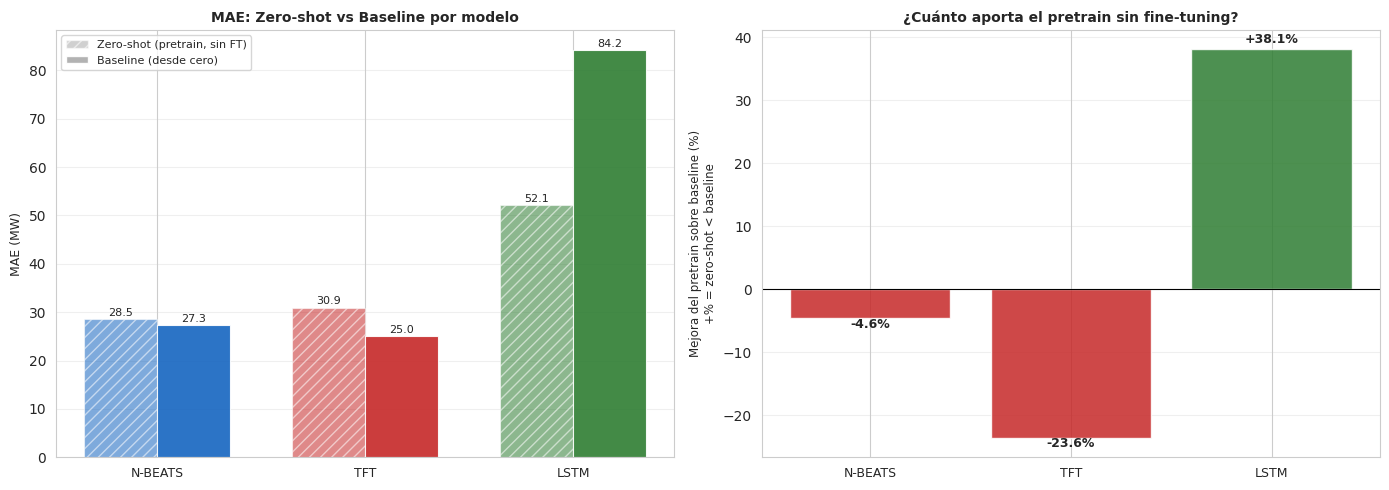

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/comparison/figures/exp2_zeroshot_vs_baseline.png

Resumen:
  N-BEATS: zero-shot es 4.6% PEOR que baseline
  TFT: zero-shot es 23.6% PEOR que baseline
  LSTM: zero-shot es 38.1% MEJOR que baseline


In [6]:
# ============================================================================
# 5. ZERO-SHOT vs BASELINE — ¿cuánto aporta el pretrain sin datos del target?
# ============================================================================
# Muestra la diferencia de MAE entre:
#   - Zero-shot (pesos pre-entrenados, sin fine-tuning en TALASOL)
#   - Baseline (pesos aleatorios, entrenado desde cero en TALASOL)
#
# Si zero-shot < baseline → el pretrain multi-planta aporta valor por sí solo.
# Si zero-shot > baseline → la transferencia requiere al menos algo de FT.

print('[5/8] Zero-shot vs Baseline...')

comp_rows = []
for modelo in modelos_disponibles:
    df_m = df_all[df_all['modelo'] == modelo]
    for sc in ['zero_shot', 'baseline']:
        row = df_m[df_m['scenario'] == sc]
        if len(row) > 0:
            comp_rows.append({
                'modelo':   modelo,
                'scenario': sc,
                'MAE':      row['MAE'].values[0],
                'R2':       row['R2'].values[0] if 'R2' in row.columns else np.nan,
            })

df_comp = pd.DataFrame(comp_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel izquierdo: Barplot MAE ─────────────────────────────────────────────
ax = axes[0]
x        = np.arange(len(modelos_disponibles))
width    = 0.35
patterns = {'zero_shot': '///', 'baseline': ''}
labels   = {'zero_shot': 'Zero-shot (pre-entrenado)', 'baseline': 'Baseline (desde cero)'}

for k, (sc, offset) in enumerate(zip(['zero_shot', 'baseline'], [-width/2, width/2])):
    mae_vals = []
    for m in modelos_disponibles:
        row = df_comp[(df_comp['modelo'] == m) & (df_comp['scenario'] == sc)]
        mae_vals.append(row['MAE'].values[0] if len(row) > 0 else np.nan)

    colors = [COLORES_MODELO.get(m, '#607D8B') for m in modelos_disponibles]
    bars = ax.bar(x + offset, mae_vals, width=width, color=colors,
                  alpha=0.9 if sc == 'baseline' else 0.55,
                  hatch=patterns[sc], edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, mae_vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.3,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(modelos_disponibles, fontsize=9)
ax.set_ylabel('MAE (MW)', fontsize=9)
ax.set_title('MAE: Zero-shot vs Baseline por modelo', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
legend_els = [
    mpatches.Patch(facecolor='#AAAAAA', hatch='///', alpha=0.55,
                   label='Zero-shot (pretrain, sin FT)'),
    mpatches.Patch(facecolor='#AAAAAA', alpha=0.9,
                   label='Baseline (desde cero)'),
]
ax.legend(handles=legend_els, fontsize=8, loc='upper left')

# ── Panel derecho: Mejora % (baseline - zero_shot) / baseline ────────────────
ax2 = axes[1]
mejora_pct = []
for m in modelos_disponibles:
    zs_row = df_comp[(df_comp['modelo'] == m) & (df_comp['scenario'] == 'zero_shot')]
    bl_row = df_comp[(df_comp['modelo'] == m) & (df_comp['scenario'] == 'baseline')]
    if len(zs_row) > 0 and len(bl_row) > 0:
        bl = bl_row['MAE'].values[0]
        zs = zs_row['MAE'].values[0]
        # Positivo = zero-shot MEJOR que baseline (pretrain ayuda)
        # Negativo = zero-shot PEOR que baseline (pretrain perjudica)
        mejora_pct.append((bl - zs) / bl * 100)
    else:
        mejora_pct.append(np.nan)

colors_bar = []
for v in mejora_pct:
    if np.isnan(v):
        colors_bar.append('#BDBDBD')
    elif v > 0:
        colors_bar.append('#2E7D32')   # verde = pretrain ayuda
    else:
        colors_bar.append('#C62828')   # rojo = pretrain no ayuda

bars2 = ax2.bar(modelos_disponibles, mejora_pct, color=colors_bar,
                 alpha=0.85, edgecolor='white')
for bar, val in zip(bars2, mejora_pct):
    if not np.isnan(val):
        ypos = val + 0.5 if val >= 0 else val - 2.0
        ax2.text(bar.get_x() + bar.get_width() / 2, ypos,
                 f'{val:+.1f}%', ha='center', va='bottom', fontsize=9,
                 fontweight='bold')

ax2.axhline(y=0, color='black', lw=0.8)
ax2.set_ylabel('Mejora del pretrain sobre baseline (%)\n+% = zero-shot < baseline', fontsize=8.5)
ax2.set_title('¿Cuánto aporta el pretrain sin fine-tuning?', fontsize=10, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', labelsize=9)

plt.tight_layout()
save_path = FIGURES_DIR / 'exp2_zeroshot_vs_baseline.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Guardado: {save_path}')

print('\nResumen:')
for m, v in zip(modelos_disponibles, mejora_pct):
    if not np.isnan(v):
        signo = 'MEJOR' if v > 0 else 'PEOR'
        print(f'  {m}: zero-shot es {abs(v):.1f}% {signo} que baseline')

[6/8] Frozen vs Full fine-tuning...


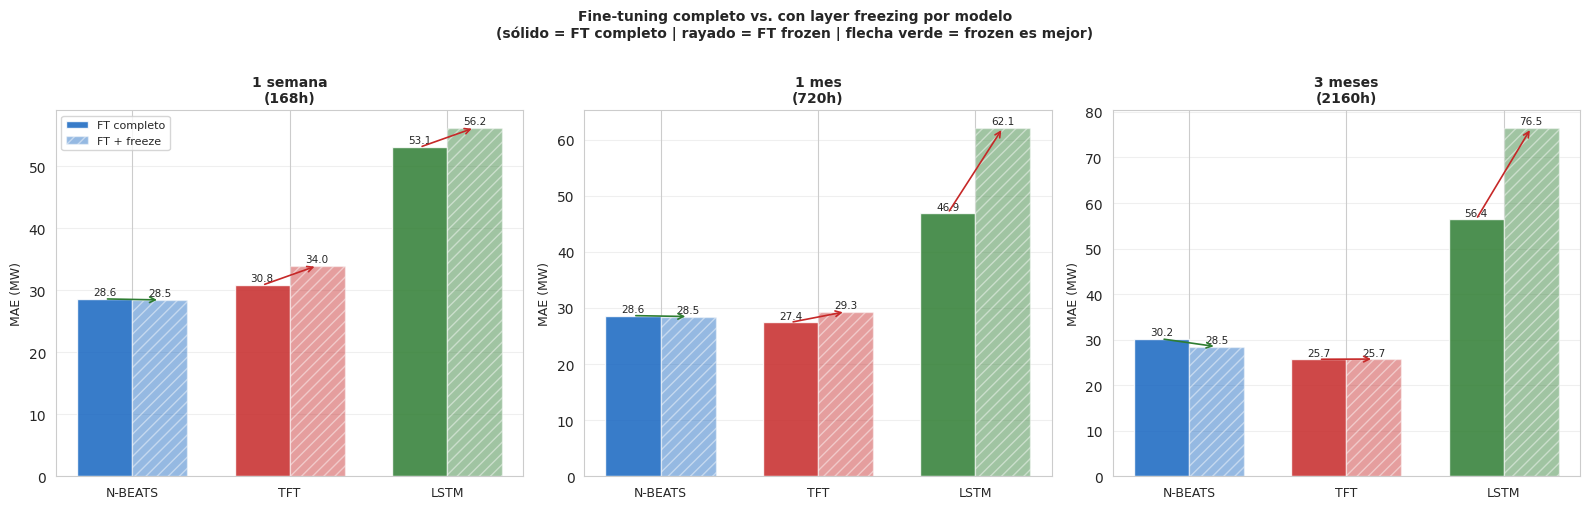

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/comparison/figures/exp2_frozen_vs_full.png

Resumen (positivo = frozen mejor):
  N-BEATS:
    1_semana: Δ=+0.16 MW (frozen mejor)
    1_mes: Δ=+0.16 MW (frozen mejor)
    3_meses: Δ=+1.72 MW (frozen mejor)
  TFT:
    1_semana: Δ=-3.16 MW (full mejor)
    1_mes: Δ=-1.90 MW (full mejor)
    3_meses: Δ=-0.05 MW (full mejor)
  LSTM:
    1_semana: Δ=-3.15 MW (full mejor)
    1_mes: Δ=-15.23 MW (full mejor)
    3_meses: Δ=-20.13 MW (full mejor)


In [7]:
# ============================================================================
# 6. FROZEN vs FULL FINE-TUNING — ¿en qué modelo ayuda más congelar capas?
# ============================================================================
# Para cada modelo y escenario de FT, comparar:
#   - FT completo (todos los pesos actualizados, LR reducido)
#   - FT frozen (capas pre-entrenadas congeladas, LR original en el resto)
#
# Resultado esperado: congelar ayuda cuando el modelo es grande (TFT > N-BEATS > LSTM)
# porque reduce el riesgo de catastrophic forgetting con pocos datos de target.

print('[6/8] Frozen vs Full fine-tuning...')

ft_size_names  = ['1_semana', '1_mes', '3_meses']
ft_size_labels = ['1 semana\n(168h)', '1 mes\n(720h)', '3 meses\n(2160h)']

fig, axes = plt.subplots(1, len(ft_size_names), figsize=(16, 5), sharey=False)

for ax, size, size_label in zip(axes, ft_size_names, ft_size_labels):
    sc_full   = f'ft_{size}'
    sc_frozen = f'ft_frozen_{size}'

    full_mae   = []
    frozen_mae = []
    for m in modelos_disponibles:
        df_m = df_all[df_all['modelo'] == m]
        row_f  = df_m[df_m['scenario'] == sc_full]
        row_fr = df_m[df_m['scenario'] == sc_frozen]
        full_mae.append(row_f['MAE'].values[0]   if len(row_f)  > 0 else np.nan)
        frozen_mae.append(row_fr['MAE'].values[0] if len(row_fr) > 0 else np.nan)

    x     = np.arange(len(modelos_disponibles))
    width = 0.35
    colors = [COLORES_MODELO.get(m, '#607D8B') for m in modelos_disponibles]

    bars1 = ax.bar(x - width / 2, full_mae,   width=width, color=colors,
                   alpha=0.85, edgecolor='white', label='FT completo')
    bars2 = ax.bar(x + width / 2, frozen_mae, width=width, color=colors,
                   alpha=0.45, hatch='///', edgecolor='white', label='FT + freeze')

    for bars, vals in [(bars1, full_mae), (bars2, frozen_mae)]:
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.3,
                        f'{val:.1f}', ha='center', va='bottom', fontsize=7.5)

    # Flechas de diferencia
    for i, (full, frz) in enumerate(zip(full_mae, frozen_mae)):
        if not (np.isnan(full) or np.isnan(frz)):
            diff = full - frz   # positivo = frozen es mejor
            ymax = max(full, frz)
            color_arr = '#2E7D32' if diff > 0 else '#C62828'
            ax.annotate('', xy=(i + width / 2, frz),
                         xytext=(i - width / 2, full),
                         arrowprops=dict(arrowstyle='->', color=color_arr,
                                         lw=1.2))

    ax.set_xticks(x)
    ax.set_xticklabels(modelos_disponibles, fontsize=9)
    ax.set_ylabel('MAE (MW)', fontsize=9)
    ax.set_title(f'{size_label}', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    if ax == axes[0]:
        ax.legend(fontsize=8)

plt.suptitle(
    'Fine-tuning completo vs. con layer freezing por modelo\n'
    '(sólido = FT completo | rayado = FT frozen | flecha verde = frozen es mejor)',
    fontsize=10, fontweight='bold', y=1.01
)
plt.tight_layout()
save_path = FIGURES_DIR / 'exp2_frozen_vs_full.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Guardado: {save_path}')

# Imprimir resumen
print('\nResumen (positivo = frozen mejor):')
for m in modelos_disponibles:
    df_m = df_all[df_all['modelo'] == m]
    print(f'  {m}:')
    for size in ft_size_names:
        row_f  = df_m[df_m['scenario'] == f'ft_{size}']
        row_fr = df_m[df_m['scenario'] == f'ft_frozen_{size}']
        if len(row_f) > 0 and len(row_fr) > 0:
            diff = row_f['MAE'].values[0] - row_fr['MAE'].values[0]
            signo = '+' if diff > 0 else ''
            print(f'    {size}: Δ={signo}{diff:.2f} MW '
                  f'({"frozen mejor" if diff > 0 else "full mejor"})')

[7/8] Análisis de similaridad de plantas...
  Features por planta: 8 variables

  Distancias euclídeas a TALASOL:
    FVARENA          dist=2.308  zona=Centro
    NBALBOA          dist=2.378  zona=Centro
    UFMULA           dist=3.644  zona=Sur
    RODRI            dist=3.920  zona=Sur
    UPGARNACHA       dist=5.261  zona=Norte


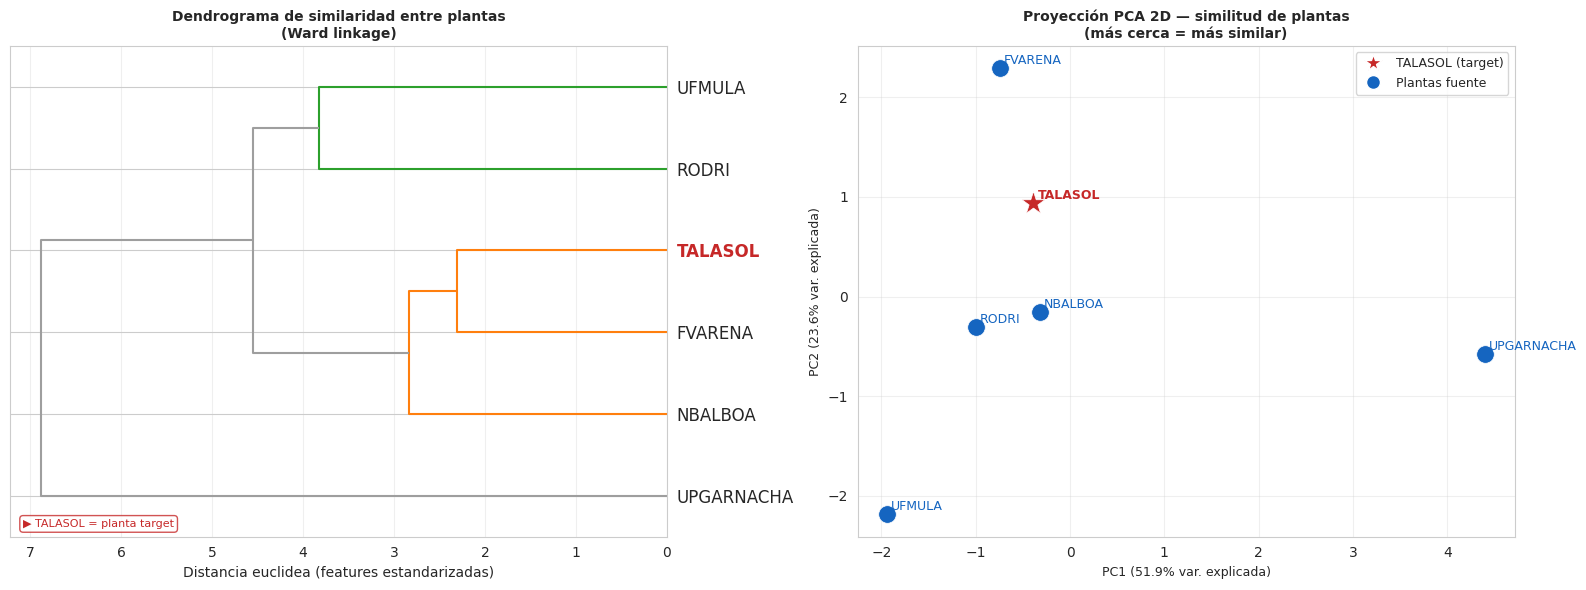


  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/comparison/figures/exp2_plant_similarity.png

  Correlación similaridad → transferencia (zero-shot):
    N-BEATS     dist_media_fuente=3.502  zero-shot=28.54 MW  baseline=27.29 MW  ratio=1.05
    TFT         dist_media_fuente=3.502  zero-shot=30.89 MW  baseline=25.00 MW  ratio=1.24
    LSTM        dist_media_fuente=3.502  zero-shot=52.14 MW  baseline=84.18 MW  ratio=0.62

  Distancias guardadas: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/comparison/plant_distances.csv


In [8]:
# ============================================================================
# 7. SIMILARIDAD DE PLANTAS → RENDIMIENTO DE TRANSFERENCIA
# ============================================================================
# Calcula la similitud entre TALASOL y cada planta fuente usando features
# meteorológicas + técnicas, y la correlaciona con el rendimiento zero-shot.
#
# Hipótesis: plantas más similares a TALASOL transferirán mejor.
# Si la correlación es alta, la similitud puede usarse como guía para
# seleccionar qué plantas fuente incluir en el pretraining.

print('[7/8] Análisis de similaridad de plantas...')

# Cargar datos de entrenamiento para calcular features agregadas
df_train = pd.read_csv(DATA_DIR / 'train.csv')
todas_plantas = PLANTAS_SOURCE + [PLANTA_TARGET]
plantas_presentes = df_train['planta_nombre'].unique().tolist()
todas_plantas = [p for p in todas_plantas if p in plantas_presentes]

if len(todas_plantas) < 2:
    print('  ⚠ Datos insuficientes para análisis de similaridad')
else:
    # ── A. Features de cada planta ────────────────────────────────────────────
    static_cols = [c for c in ['instalada_mw', 'zona_climatica_encoded',
                                'seguimiento_encoded']
                   if c in df_train.columns]
    meteo_cols  = [c for c in ['shortwave_radiation', 'cloud_cover',
                                'temperature_2m', 'GTI', 'DNI']
                   if c in df_train.columns]

    df_static = (
        df_train
        .groupby('planta_nombre')[static_cols]
        .first()
        .reindex(todas_plantas)
        if static_cols else pd.DataFrame(index=todas_plantas)
    )

    df_meteo_mean = (
        df_train[df_train['planta_nombre'].isin(todas_plantas)]
        .groupby('planta_nombre')[meteo_cols]
        .mean()
        .reindex(todas_plantas)
        .add_suffix('_mean')
        if meteo_cols else pd.DataFrame(index=todas_plantas)
    )

    df_meteo_std = (
        df_train[df_train['planta_nombre'].isin(todas_plantas)]
        .groupby('planta_nombre')[meteo_cols]
        .std()
        .reindex(todas_plantas)
        .add_suffix('_std')
        if meteo_cols else pd.DataFrame(index=todas_plantas)
    )

    prod_mean = (
        df_train[df_train['planta_nombre'].isin(todas_plantas)]
        .groupby('planta_nombre')['produccion'].mean()
        .reindex(todas_plantas)
    )
    if 'instalada_mw' in df_train.columns:
        cap_kw = (
            df_train.groupby('planta_nombre')['instalada_mw'].first()
            .reindex(todas_plantas) * 1000
        )
        cf = (prod_mean / (cap_kw + 1e-6)).rename('capacity_factor')
    else:
        cf = prod_mean.rename('capacity_factor')

    df_feat = pd.concat([df_static, df_meteo_mean, df_meteo_std, cf],
                         axis=1).fillna(0)
    print(f'  Features por planta: {df_feat.shape[1]} variables')

    # ── B. Distancias euclídeas ────────────────────────────────────────────────
    scaler  = StandardScaler()
    X       = scaler.fit_transform(df_feat.values)
    labels  = df_feat.index.tolist()
    dist_sq = squareform(pdist(X, metric='euclidean'))
    df_dist = pd.DataFrame(dist_sq, index=labels, columns=labels)

    print(f'\n  Distancias euclídeas a {PLANTA_TARGET}:')
    dist_to_target = (
        df_dist[PLANTA_TARGET]
        .drop(PLANTA_TARGET, errors='ignore')
        .sort_values()
    )
    for p, d in dist_to_target.items():
        zona = df_train[df_train['planta_nombre'] == p]['zona_climatica'].iloc[0] \
               if 'zona_climatica' in df_train.columns and \
                  len(df_train[df_train['planta_nombre'] == p]) > 0 else '?'
        print(f'    {p:<15}  dist={d:.3f}  zona={zona}')

    # ── C. Dendrograma + PCA ──────────────────────────────────────────────────
    fig, axes_sim = plt.subplots(1, 2, figsize=(16, 6))

    # Dendrograma
    ax_d = axes_sim[0]
    linked = linkage(pdist(X, metric='euclidean'), method='ward')
    dendrogram(linked, labels=labels, orientation='left', ax=ax_d,
               color_threshold=0.65 * linked[-1, 2],
               above_threshold_color='#9E9E9E')
    for lbl in ax_d.get_yticklabels():
        if lbl.get_text() == PLANTA_TARGET:
            lbl.set_color('#C62828')
            lbl.set_fontweight('bold')
    ax_d.set_title('Dendrograma de similaridad entre plantas\n(Ward linkage)',
                    fontsize=10, fontweight='bold')
    ax_d.set_xlabel('Distancia euclidea (features estandarizadas)')
    ax_d.grid(axis='x', alpha=0.3)
    ax_d.annotate(f'▶ {PLANTA_TARGET} = planta target',
                   xy=(0.02, 0.02), xycoords='axes fraction',
                   fontsize=8, color='#C62828',
                   bbox=dict(boxstyle='round,pad=0.3', fc='white',
                             ec='#C62828', alpha=0.8))

    # PCA 2D
    ax_p = axes_sim[1]
    pca   = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    var_e = pca.explained_variance_ratio_ * 100

    for planta, xp in zip(labels, X_pca):
        is_target = (planta == PLANTA_TARGET)
        col    = '#C62828' if is_target else '#1565C0'
        marker = '*' if is_target else 'o'
        size   = 300 if is_target else 160
        ax_p.scatter(xp[0], xp[1], c=col, s=size, marker=marker,
                      zorder=3, edgecolors='white', linewidths=0.5)
        offset = (0.06, 0.04) if is_target else (0.04, 0.04)
        ax_p.annotate(planta, (xp[0] + offset[0], xp[1] + offset[1]),
                       fontsize=9, color=col,
                       fontweight='bold' if is_target else 'normal')

    ax_p.set_xlabel(f'PC1 ({var_e[0]:.1f}% var. explicada)', fontsize=9)
    ax_p.set_ylabel(f'PC2 ({var_e[1]:.1f}% var. explicada)', fontsize=9)
    ax_p.set_title('Proyección PCA 2D — similitud de plantas\n'
                    '(más cerca = más similar)', fontsize=10, fontweight='bold')
    legend_els = [
        Line2D([0], [0], marker='*', color='w', markerfacecolor='#C62828',
                markersize=13, label=f'{PLANTA_TARGET} (target)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#1565C0',
                markersize=10, label='Plantas fuente'),
    ]
    ax_p.legend(handles=legend_els, fontsize=9)
    ax_p.grid(alpha=0.3)

    plt.tight_layout()
    save_path = FIGURES_DIR / 'exp2_plant_similarity.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\n  Guardado: {save_path}')

    # ── D. Correlación distancia → MAE zero-shot ──────────────────────────────
    # Distancia media de las plantas fuente a TALASOL vs MAE zero-shot
    source_only = [p for p in PLANTAS_SOURCE if p in dist_to_target.index]
    dist_mean = dist_to_target[source_only].mean()   # distancia media del conjunto fuente
    dist_vals = [dist_to_target.get(p, np.nan) for p in source_only]

    print('\n  Correlación similaridad → transferencia (zero-shot):')
    for modelo in modelos_disponibles:
        df_m   = df_all[df_all['modelo'] == modelo]
        row_zs = df_m[df_m['scenario'] == 'zero_shot']
        row_bl = df_m[df_m['scenario'] == 'baseline']
        if len(row_zs) > 0 and len(row_bl) > 0:
            mae_zs = row_zs['MAE'].values[0]
            mae_bl = row_bl['MAE'].values[0]
            print(f'    {modelo:<10}  dist_media_fuente={dist_mean:.3f}  '
                  f'zero-shot={mae_zs:.2f} MW  baseline={mae_bl:.2f} MW  '
                  f'ratio={mae_zs/mae_bl:.2f}')

    # Guardar distancias como CSV auxiliar
    df_dist.to_csv(RESULTS_CMP / 'plant_distances.csv')
    print(f'\n  Distancias guardadas: {RESULTS_CMP}/plant_distances.csv')

[8/8] Tabla resumen final...

RESUMEN: MEJOR ESCENARIO DE TRANSFERENCIA POR MODELO
 modelo    mejor_escenario  n_ft_hours  MAE_best  R2_best  MAE_zero_shot  MAE_baseline  mejora_vs_baseline_%  mejora_vs_zeroshot_%
N-BEATS ft_frozen_1_semana         168   28.4610   0.8882        28.5360       27.2870               -4.3024                0.2628
    TFT         ft_3_meses        2160   25.6961   0.9049        30.8913       24.9984               -2.7910               16.8177
   LSTM           ft_1_mes         720   46.8656   0.7184        52.1449       84.1844               44.3298               10.1243

Exportado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/comparison/exp2_best_per_model.csv
Exportado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/comparison/exp2_all_scenarios.csv


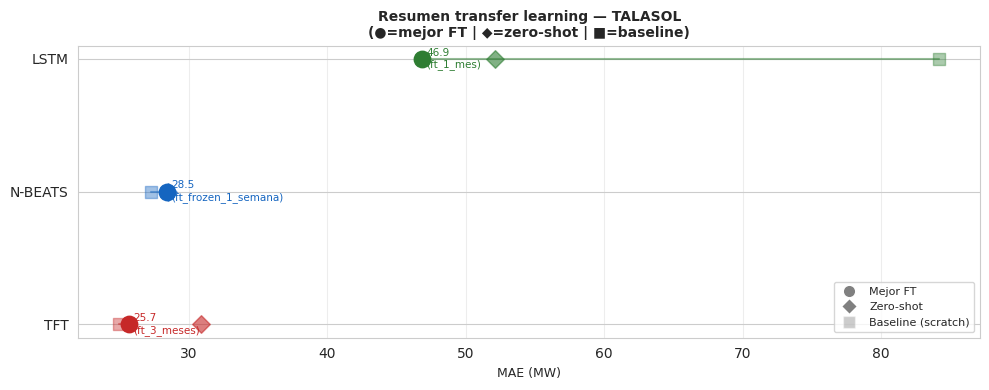


  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/comparison/figures/exp2_transfer_summary_lollipop.png

EXPERIMENTO 2 — COMPARACIÓN UNIFICADA COMPLETADA
  Figuras   : /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/comparison/figures
  CSVs      : /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/comparison


In [9]:
# ============================================================================
# 8. TABLA RESUMEN Y EXPORT
# ============================================================================
# Tabla final: mejor escenario por modelo, mejora % vs baseline.
# Export a CSV para uso en la tesis y en ex4_valuation.

print('[8/8] Tabla resumen final...')

# ── Tabla 1: Mejor escenario por modelo ──────────────────────────────────────
best_rows = []
for modelo in modelos_disponibles:
    df_m = df_all[df_all['modelo'] == modelo]

    # Excluir 'baseline' del ranking de transfer (es la cota de referencia)
    df_transfer = df_m[df_m['scenario'] != 'baseline']
    if len(df_transfer) == 0:
        continue

    best_idx = df_transfer['MAE'].idxmin()
    best_row = df_transfer.loc[best_idx].copy()

    # Añadir MAE baseline como referencia
    bl_row = df_m[df_m['scenario'] == 'baseline']
    bl_mae = bl_row['MAE'].values[0] if len(bl_row) > 0 else np.nan
    zs_row = df_m[df_m['scenario'] == 'zero_shot']
    zs_mae = zs_row['MAE'].values[0] if len(zs_row) > 0 else np.nan

    best_rows.append({
        'modelo':               modelo,
        'mejor_escenario':      best_row['scenario'],
        'n_ft_hours':           FT_HOURS.get(best_row['scenario'], np.nan),
        'MAE_best':             best_row['MAE'],
        'R2_best':              best_row['R2'] if 'R2' in best_row else np.nan,
        'MAE_zero_shot':        zs_mae,
        'MAE_baseline':         bl_mae,
        'mejora_vs_baseline_%': (bl_mae - best_row['MAE']) / bl_mae * 100
                                 if not np.isnan(bl_mae) else np.nan,
        'mejora_vs_zeroshot_%': (zs_mae - best_row['MAE']) / zs_mae * 100
                                 if not np.isnan(zs_mae) else np.nan,
    })

df_best = pd.DataFrame(best_rows)

print('\n' + '=' * 80)
print('RESUMEN: MEJOR ESCENARIO DE TRANSFERENCIA POR MODELO')
print('=' * 80)
print(df_best.to_string(index=False))

# ── Tabla 2: Todos los escenarios para la tesis ───────────────────────────────
_export_want = ['modelo', 'scenario', 'MAE', 'RMSE', 'MAPE', 'R2',
                'training_time_s', 'mejora_vs_baseline_%', 'mejora_vs_zeroshot_%']
cols_ok = [c for c in _export_want if c in df_all.columns]
df_export = df_all[cols_ok].copy()

# Export CSVs
path_best = RESULTS_CMP / 'exp2_best_per_model.csv'
path_all  = RESULTS_CMP / 'exp2_all_scenarios.csv'
df_best.to_csv(path_best,   index=False)
df_all.to_csv(path_all, index=False)
print(f'\nExportado: {path_best}')
print(f'Exportado: {path_all}')

# ── Figura resumen: lollipop MAE mejor escenario ──────────────────────────────
if len(df_best) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))

    modelos_sorted = df_best.sort_values('MAE_best')['modelo'].tolist()
    y  = np.arange(len(modelos_sorted))

    for i, m in enumerate(modelos_sorted):
        row   = df_best[df_best['modelo'] == m].iloc[0]
        color = COLORES_MODELO.get(m, '#607D8B')

        mae_best = row['MAE_best']
        mae_bl   = row['MAE_baseline']
        mae_zs   = row['MAE_zero_shot']

        # Línea desde baseline hasta best
        if not np.isnan(mae_bl):
            ax.plot([mae_bl, mae_best], [i, i], '-', color=color, lw=1.5,
                     alpha=0.5, zorder=2)
            ax.scatter(mae_bl, i, s=80, marker='s', color=color, alpha=0.4,
                        zorder=3, label='_nolegend_')

        # Punto zero-shot
        if not np.isnan(mae_zs):
            ax.scatter(mae_zs, i, s=80, marker='D', color=color, alpha=0.6,
                        zorder=3)

        # Punto best
        ax.scatter(mae_best, i, s=140, marker='o', color=color, zorder=4)
        ax.text(mae_best + 0.3, i,
                f'{mae_best:.1f}\n({row["mejor_escenario"]})',
                va='center', fontsize=7.5, color=color)

    ax.set_yticks(y)
    ax.set_yticklabels(modelos_sorted, fontsize=10)
    ax.set_xlabel('MAE (MW)', fontsize=9)
    ax.set_title(
        f'Resumen transfer learning — {PLANTA_TARGET}\n'
        '(●=mejor FT | ◆=zero-shot | ■=baseline)',
        fontsize=10, fontweight='bold'
    )
    legend_els = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                markersize=9, label='Mejor FT'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='gray',
                markersize=8, label='Zero-shot'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',
                markersize=8, alpha=0.4, label='Baseline (scratch)'),
    ]
    ax.legend(handles=legend_els, fontsize=8, loc='lower right')
    ax.grid(axis='x', alpha=0.35)

    plt.tight_layout()
    save_path = FIGURES_DIR / 'exp2_transfer_summary_lollipop.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\n  Guardado: {save_path}')

print('\n' + '=' * 70)
print('EXPERIMENTO 2 — COMPARACIÓN UNIFICADA COMPLETADA')
print(f'  Figuras   : {FIGURES_DIR}')
print(f'  CSVs      : {RESULTS_CMP}')
print('=' * 70)